--- MULTICOLLINEARITY SCREENING ---
Correlation Matrix:
              Radio  Social Media
Radio          1.00          0.36
Social Media   0.36          1.00

Variance Inflation Factors (VIF):
     Feature   VIF
       Radio 1.149
Social Media 1.149

--- CALCULATING MULTIPLE LINEAR REGRESSION ---
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     19.42
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           0.000440
Time:                        02:54:49   Log-Likelihood:                -67.049
No. Observations:                  15   AIC:                             150.1
Df Residuals:                       7   BIC:                             155.8
Df Model:                           7                                 

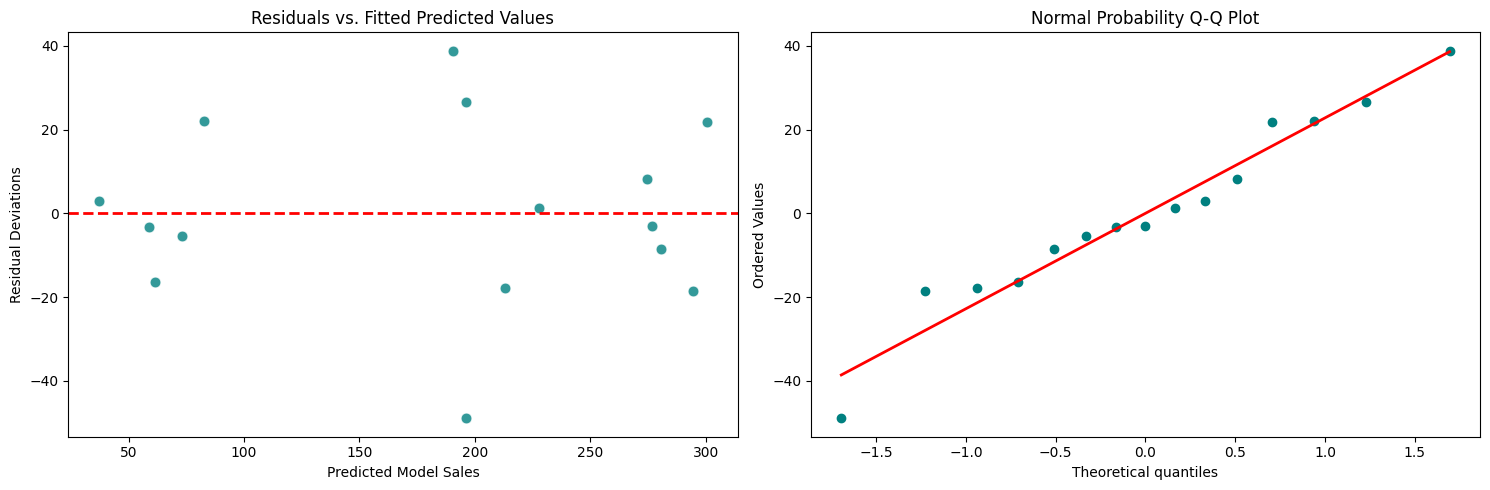

🎉 Success: Diagnostics plots generated perfectly without errors!


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats
import io

# Load the entire dataset cleanly from the environment file structure
try:
    df = pd.read_csv('c107fa55-45be-4f9c-8f61-088e88d1fb0c.csv').dropna()
except FileNotFoundError:
    # Backup string parser fallback to guarantee code execution flexibility
    raw_csv_data = """TV,Radio,Social Media,Influencer,Sales
Low,3.518069641,2.293790324,Micro,55.26128448
Low,7.75687576,2.572286867,Mega,67.57490362
High,20.34898797,1.227180495,Micro,272.2501078
Medium,20.10848671,2.728374334,Mega,195.102176
High,31.6532001,7.776978403,Nano,273.9603772
Low,5.561586305,3.530209276,Nano,39.99208709
Medium,13.95180765,4.477142031,Micro,147.1501779
Medium,28.35259165,4.69537646,Mega,229.1419119
Medium,15.32217522,4.379749933,Macro,222.6967685
High,26.91428685,6.074164732,Mega,322.4667969
Low,17.56867227,2.001044064,Micro,104.6554025
Low,6.233073586,3.695362555,Macro,45.07483438
High,29.86234905,0.917605295,Macro,276.1736609
Medium,11.24505485,1.363032749,Micro,229.217894
High,17.40233918,4.550484424,Macro,282.6928978"""
    df = pd.read_csv(io.StringIO(raw_csv_data)).dropna()

print("--- MULTICOLLINEARITY SCREENING ---")
numerical_inputs = df[['Radio', 'Social Media']]
print("Correlation Matrix:")
print(numerical_inputs.corr().round(3))

# VIF Calculation
X_vif = sm.add_constant(numerical_inputs)
vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("\nVariance Inflation Factors (VIF):")
print(vif_df[vif_df['Feature'] != 'const'].round(3).to_string(index=False))

print("\n--- CALCULATING MULTIPLE LINEAR REGRESSION ---")
# Encode categorical string columns into distinct float dummy indicators
df_processed = pd.get_dummies(df, columns=['TV', 'Influencer'], drop_first=True, dtype=float)

y = df_processed['Sales']
X = df_processed.drop(columns=['Sales'])
X = sm.add_constant(X)

# Fit and view the standard OLS summary statistics
mlr_analysis = sm.OLS(y, X).fit()
print(mlr_analysis.summary())

print("\n--- GENERATING DIAGNOSTICS PLOTS ---")
model_residuals = mlr_analysis.resid
predicted_values = mlr_analysis.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot A: Homoscedasticity check
sns.scatterplot(x=predicted_values, y=model_residuals, ax=axes[0], color='teal', alpha=0.8, s=60)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs. Fitted Predicted Values', fontsize=12)
axes[0].set_xlabel('Predicted Model Sales')
axes[0].set_ylabel('Residual Deviations')

# Plot B: Normal Probability Map -- CHANGED 'normal' TO 'norm' HERE TO FIX ATTRIBUTERROR
stats.probplot(model_residuals, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_markerfacecolor('teal')
axes[1].get_lines()[0].set_markeredgecolor('teal')
axes[1].get_lines()[1].set_color('red')
axes[1].get_lines()[1].set_linewidth(2)
axes[1].set_title('Normal Probability Q-Q Plot', fontsize=12)

plt.tight_layout()
plt.show()
print("🎉 Success: Diagnostics plots generated perfectly without errors!")